<a href="https://colab.research.google.com/github/Lio72rga/Mineria-de-Datos-2026/blob/main/Notebook_2_Regresion_Logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 - Regresión Logística

## Predicción de Supervivencia en el Titanic

Autor: Lionel Martinez

# Introducción

La Regresión Logística es un algoritmo de aprendizaje supervisado utilizado para problemas de clasificación.

En este notebook utilizaremos el dataset Titanic para predecir si un pasajero sobrevivió o no al accidente, utilizando variables como:

- Edad
- Tarifa del boleto
- Sexo

La variable objetivo será:

- 0 = No sobrevivió
- 1 = Sobrevivió

In [5]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:

df = sns.load_dataset("titanic").dropna()

df["sex"] = df["sex"].map({"male":1, "female":0})

X = df[["age", "fare", "sex"]]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6486486486486487
[[ 8  5]
 [ 8 16]]
              precision    recall  f1-score   support

           0       0.50      0.62      0.55        13
           1       0.76      0.67      0.71        24

    accuracy                           0.65        37
   macro avg       0.63      0.64      0.63        37
weighted avg       0.67      0.65      0.66        37



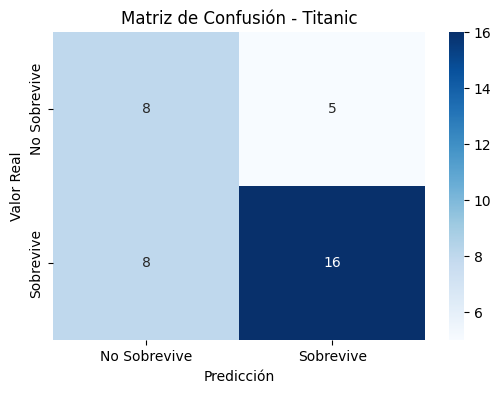

In [3]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Sobrevive","Sobrevive"],
            yticklabels=["No Sobrevive","Sobrevive"])

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Titanic")

plt.show()

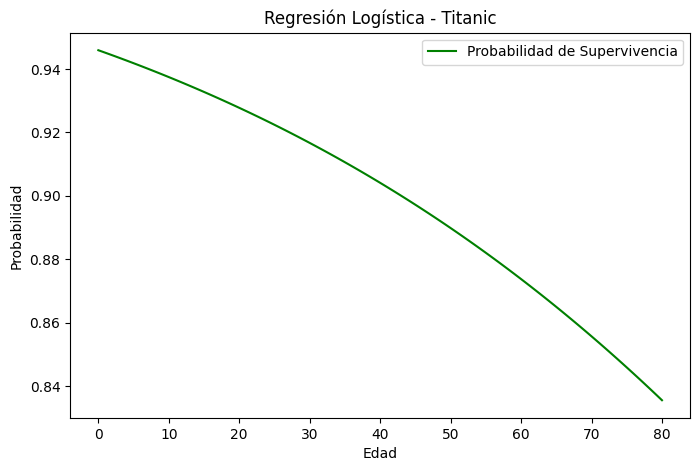

In [6]:
# Valores de edad
age_test = np.linspace(0, 80, 100)

# Valor promedio de fare
fare_mean = df["fare"].mean()

# Sexo femenino fijo
sex_fixed = 0

# Crear dataframe
X_test_graph = pd.DataFrame({
    "age": age_test,
    "fare": [fare_mean] * 100,
    "sex": [sex_fixed] * 100
})

# Probabilidades
y_prob = model.predict_proba(X_test_graph)[:,1]

# Gráfico
plt.figure(figsize=(8,5))

plt.plot(age_test,
         y_prob,
         color="green",
         label="Probabilidad de Supervivencia")

plt.xlabel("Edad")
plt.ylabel("Probabilidad")
plt.title("Regresión Logística - Titanic")

plt.legend()

plt.show()

# Interpretación de Resultados

La matriz de confusión permite visualizar:

- Verdaderos positivos
- Verdaderos negativos
- Falsos positivos
- Falsos negativos

El modelo obtuvo una precisión aproximada del 65%, lo que indica que puede identificar correctamente una parte importante de los pasajeros sobrevivientes.

El gráfico logístico muestra cómo cambia la probabilidad de supervivencia según la edad del pasajero.

# Regresión Logística vs Regresión Lineal

## Regresión Logística
- Se utiliza para clasificación.
- Predice categorías.
- Genera probabilidades entre 0 y 1.

## Regresión Lineal
- Se utiliza para regresión.
- Predice valores numéricos continuos.
- No trabaja con probabilidades.

# Conclusión

En este notebook se aplicó un modelo de Regresión Logística sobre el dataset Titanic para predecir la supervivencia de los pasajeros.

El modelo logró una precisión aceptable utilizando variables simples como edad, tarifa y sexo.

La matriz de confusión permitió evaluar los errores y aciertos del modelo, mientras que el gráfico logístico mostró la relación entre la edad y la probabilidad de supervivencia.

La Regresión Logística es una herramienta fundamental en problemas de clasificación binaria dentro del aprendizaje supervisado.